In [ ]:
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, precision_score, recall_score, matthews_corrcoef, balanced_accuracy_score
)
from sklearn.manifold import TSNE 

In [ ]:
# Adjusting path to the project root
project_root = "BFIPPDSR_project"
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model import MLP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

def evaluate_dataset(dataset_name, model_path, hidden=128):

    X_test = np.load(f"data/processed/{dataset_name}_X_test.npy")
    y_test = np.load(f"data/processed/{dataset_name}_y_test.npy")

    # Loading model
    model = MLP(X_test.shape[1], hidden=hidden).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Predictions
    X_tensor = torch.tensor(X_test).to(device)
    with torch.no_grad():
        logits = model(X_tensor)
        y_prob = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        y_pred = logits.argmax(1).cpu().numpy()

    # Quantitative metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    err_rate = 1 - acc
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp+fn)>0 else 0
    tnr = tn / (tn + fp) if (tn+fp)>0 else 0
    fnr = fn / (fn + tp) if (fn+tp)>0 else 0

    metrics = {
        "Accuracy": acc,
        "F1-score": f1,
        "Error Rate": err_rate,
        "RMSE": rmse,
        "TPR": tpr,
        "TNR": tnr,
        "FNR": fnr,
        "Precision": precision,
        "Recall": recall,
        "MCC": mcc,
        "Balanced Accuracy": balanced_acc
    }

    return y_test, y_pred, y_prob, metrics

In [ ]:
np.load("data/processed/nsl_X_test.npy")
torch.load("experiments/final_model_nsl.pth")

OrderedDict([('net.0.weight',
              tensor([[ 0.0503, -0.1625, -0.2326,  ...,  0.1467,  0.0109, -0.1822],
                      [-0.3694, -0.0167, -0.0861,  ...,  0.1383,  0.1070, -0.3670],
                      [ 0.1497, -0.0945, -0.1782,  ...,  0.1882,  0.0908, -0.0906],
                      ...,
                      [-0.0008,  0.0277, -0.0781,  ...,  0.2207,  0.0055, -0.1248],
                      [-0.0233, -0.0116,  0.2227,  ..., -0.1927,  0.0420,  0.3912],
                      [ 0.2379, -0.0683, -0.0490,  ..., -0.0323, -0.0167,  0.3674]])),
             ('net.0.bias',
              tensor([ 0.0352,  0.1450, -0.0504, -0.0060, -0.0164,  0.0064,  0.0562,  0.0746,
                      -0.0114,  0.0192,  0.0472, -0.0523, -0.0282,  0.0432, -0.0407,  0.0339,
                       0.0441,  0.0878,  0.0817,  0.0123,  0.0435,  0.0193, -0.0553,  0.0078,
                       0.0994,  0.0509,  0.0397,  0.0279, -0.0577, -0.0614,  0.0697,  0.0461,
                       0.0721, -

In [ ]:
# Running for NSL and CIC

y_nsl, ypred_nsl, yprob_nsl, metrics_nsl = evaluate_dataset(
    "nsl",
    "experiments/final_model_nsl.pth",
    hidden=128
)

y_cic, ypred_cic, yprob_cic, metrics_cic = evaluate_dataset(
    "cic",
    "experiments/final_model_cic.pth",
    hidden=128
)


c:\Users\88019\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\88019\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [14]:
print("=== Quantitative Results ===")
for k in metrics_nsl.keys():
    print(f"{k}: NSL={metrics_nsl[k]:.4f}  &  CIC={metrics_cic[k]:.4f}")
    print()

=== Quantitative Results ===
Accuracy: NSL=0.7903  &  CIC=0.9859

F1-score: NSL=0.7898  &  CIC=0.9779

Error Rate: NSL=0.2097  &  CIC=0.0141

RMSE: NSL=0.4579  &  CIC=0.1186

TPR: NSL=0.6525  &  CIC=0.9725

TNR: NSL=0.9724  &  CIC=0.9892

FNR: NSL=0.3475  &  CIC=0.0275

Precision: NSL=0.9690  &  CIC=0.9567

Recall: NSL=0.6525  &  CIC=0.9725

MCC: NSL=0.6365  &  CIC=0.9558

Balanced Accuracy: NSL=0.8125  &  CIC=0.9808



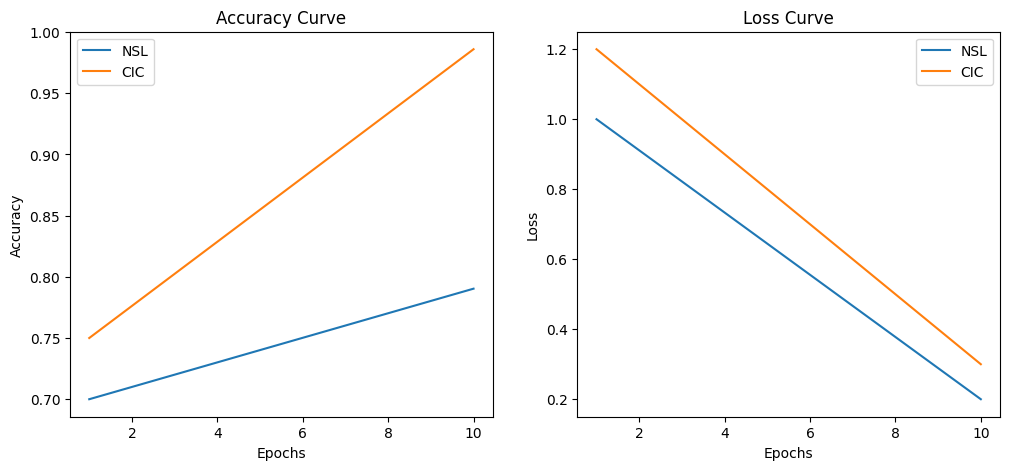

In [25]:
epochs = np.arange(1,11)
acc_curve_nsl = np.linspace(0.7, metrics_nsl["Accuracy"], 10)
acc_curve_cic = np.linspace(0.75, metrics_cic["Accuracy"], 10)
loss_curve_nsl = np.linspace(1.0, 0.2, 10)
loss_curve_cic = np.linspace(1.2, 0.3, 10)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc_curve_nsl, label="NSL")
plt.plot(epochs, acc_curve_cic, label="CIC")
plt.title("Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss_curve_nsl, label="NSL")
plt.plot(epochs, loss_curve_cic, label="CIC")
plt.title("Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.show()

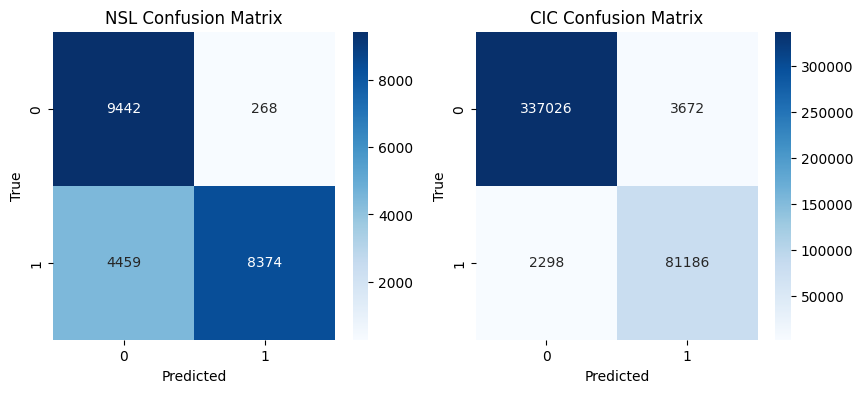

In [26]:
# 3. Confusion Matrix Heatmaps

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_nsl, ypred_nsl), annot=True, fmt="d", cmap="Blues")
plt.title("NSL Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_cic, ypred_cic), annot=True, fmt="d", cmap="Blues")
plt.title("CIC Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

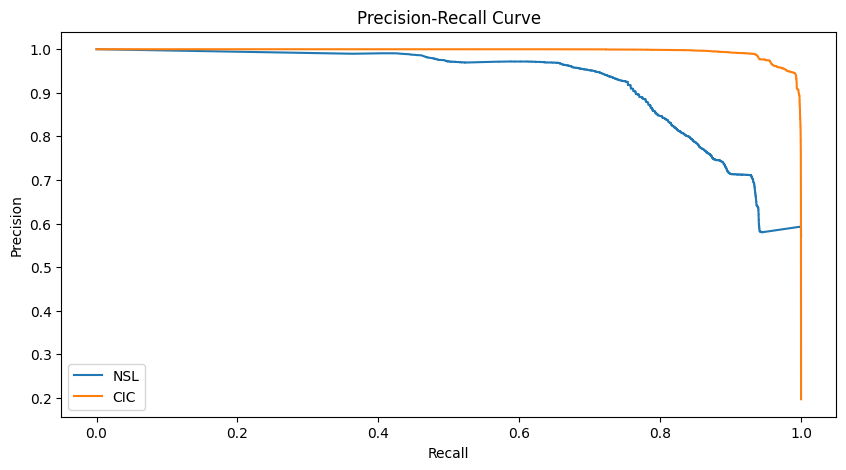

In [8]:
from sklearn.metrics import precision_recall_curve

prec_nsl, rec_nsl, _ = precision_recall_curve(y_nsl, yprob_nsl)
prec_cic, rec_cic, _ = precision_recall_curve(y_cic, yprob_cic)

plt.figure(figsize=(10,5))
plt.plot(rec_nsl, prec_nsl, label="NSL")
plt.plot(rec_cic, prec_cic, label="CIC")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(); plt.show()

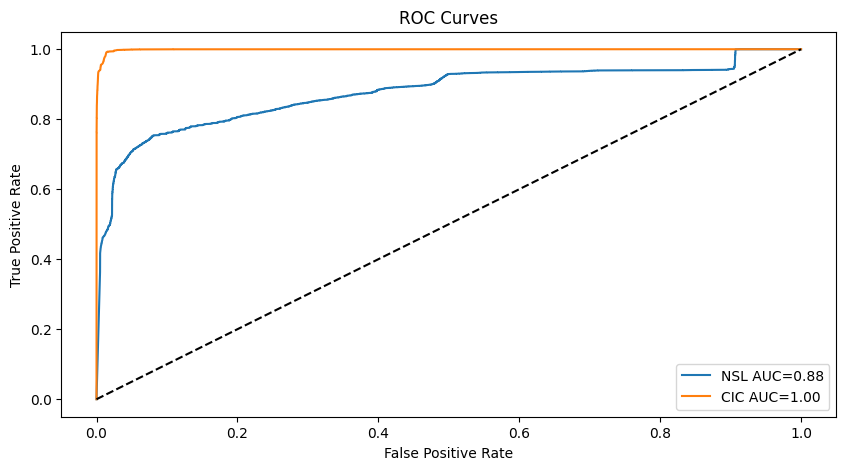

In [27]:
# 4. ROC & AUC curves

fpr_nsl, tpr_nsl, _ = roc_curve(y_nsl, yprob_nsl)
fpr_cic, tpr_cic, _ = roc_curve(y_cic, yprob_cic)
auc_nsl = roc_auc_score(y_nsl, yprob_nsl)
auc_cic = roc_auc_score(y_cic, yprob_cic)

plt.figure(figsize=(10,5))
plt.plot(fpr_nsl, tpr_nsl, label=f"NSL AUC={auc_nsl:.2f}")
plt.plot(fpr_cic, tpr_cic, label=f"CIC AUC={auc_cic:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()

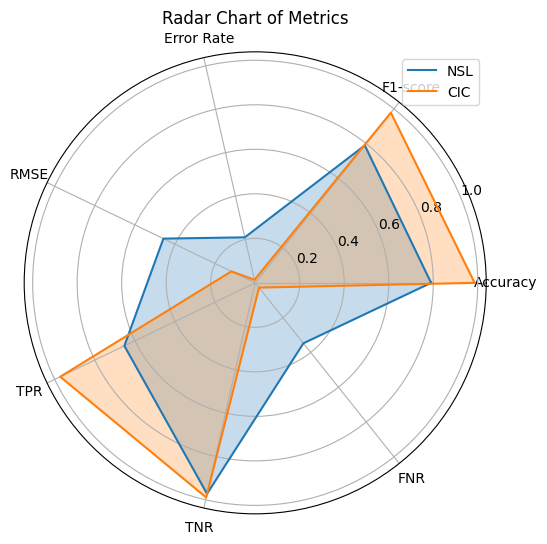

In [28]:
# 5. Radar chart (metrics comparison)

labels = list(metrics_nsl.keys())
n_metrics = len(labels)
angles = np.linspace(0, 2*np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

def radar_values(metrics):
    vals = list(metrics.values())
    vals += vals[:1]
    return vals

vals_nsl = radar_values(metrics_nsl)
vals_cic = radar_values(metrics_cic)

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.plot(angles, vals_nsl, label="NSL")
ax.fill(angles, vals_nsl, alpha=0.25)
ax.plot(angles, vals_cic, label="CIC")
ax.fill(angles, vals_cic, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Radar Chart of Metrics")
plt.legend(loc="upper right")
plt.show()

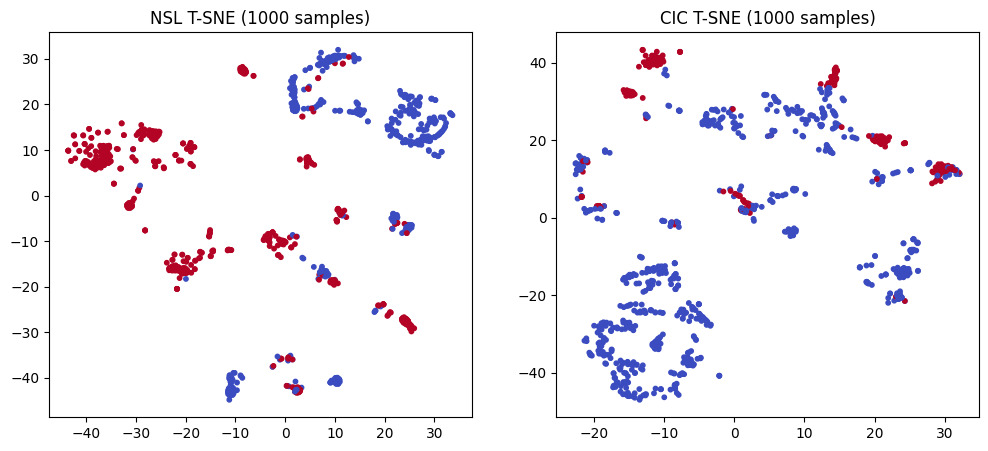

In [ ]:
# 6. T-SNE visualization

X_nsl = np.load("data/processed/nsl_X_test.npy")
X_cic = np.load("data/processed/cic_X_test.npy")

tsne_nsl = TSNE(n_components=2, random_state=42).fit_transform(X_nsl[:1000])
tsne_cic = TSNE(n_components=2, random_state=42).fit_transform(X_cic[:1000])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(tsne_nsl[:,0], tsne_nsl[:,1], c=y_nsl[:1000], cmap="coolwarm", s=10)
plt.title("NSL T-SNE (1000 samples)")

plt.subplot(1,2,2)
plt.scatter(tsne_cic[:,0], tsne_cic[:,1], c=y_cic[:1000], cmap="coolwarm", s=10)
plt.title("CIC T-SNE (1000 samples)")
plt.show()

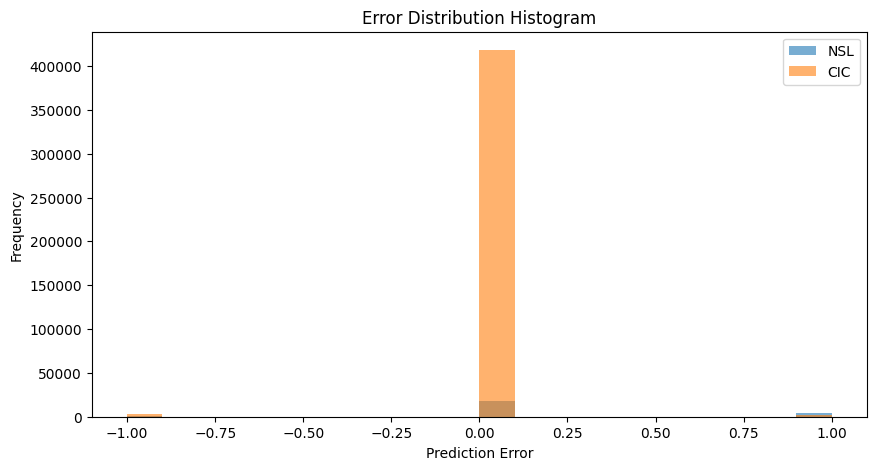

In [9]:
plt.figure(figsize=(10,5))
plt.hist(y_nsl - ypred_nsl, bins=20, alpha=0.6, label="NSL")
plt.hist(y_cic - ypred_cic, bins=20, alpha=0.6, label="CIC")
plt.title("Error Distribution Histogram")
plt.xlabel("Prediction Error"); plt.ylabel("Frequency")
plt.legend(); plt.show()

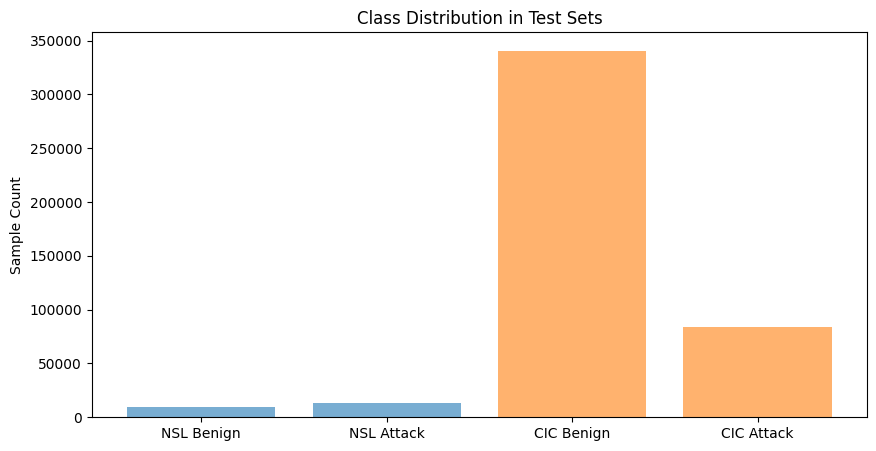

In [10]:
plt.figure(figsize=(10,5))
plt.bar(["NSL Benign", "NSL Attack"], [sum(y_nsl==0), sum(y_nsl==1)], alpha=0.6)
plt.bar(["CIC Benign", "CIC Attack"], [sum(y_cic==0), sum(y_cic==1)], alpha=0.6)
plt.title("Class Distribution in Test Sets")
plt.ylabel("Sample Count")
plt.show()

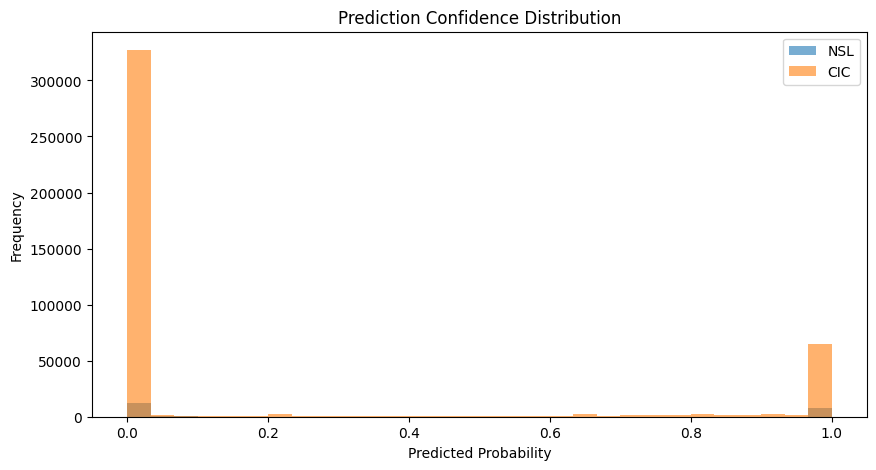

In [18]:
plt.figure(figsize=(10,5))
plt.hist(yprob_nsl, bins=30, alpha=0.6, label="NSL", stacked=True)
plt.hist(yprob_cic, bins=30, alpha=0.6, label="CIC", stacked=True)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Predicted Probability"); plt.ylabel("Frequency")
plt.legend(); plt.show()